In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## 1. Data Loading
Pada langkah ini, dataset CAD Alizadeh dibaca dari file Excel ke dalam DataFrame bernama `df`. DataFrame ini menjadi sumber data utama untuk proses klasifikasi pada langkah berikutnya.

In [2]:
df = pd.read_excel('CADalizadeh.xls')

## 1.1 Visualisasi Awal Data
Pada tahap awal ini, data divisualisasikan untuk melihat distribusi kelas target dan jumlah nilai hilang pada setiap kolom. Visualisasi ini penting agar kita memahami kondisi data sebelum masuk ke tahap preprocessing dan pemodelan.

C:\Users\Muflih Rafif\AppData\Local\Temp\ipykernel_36752\645312690.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


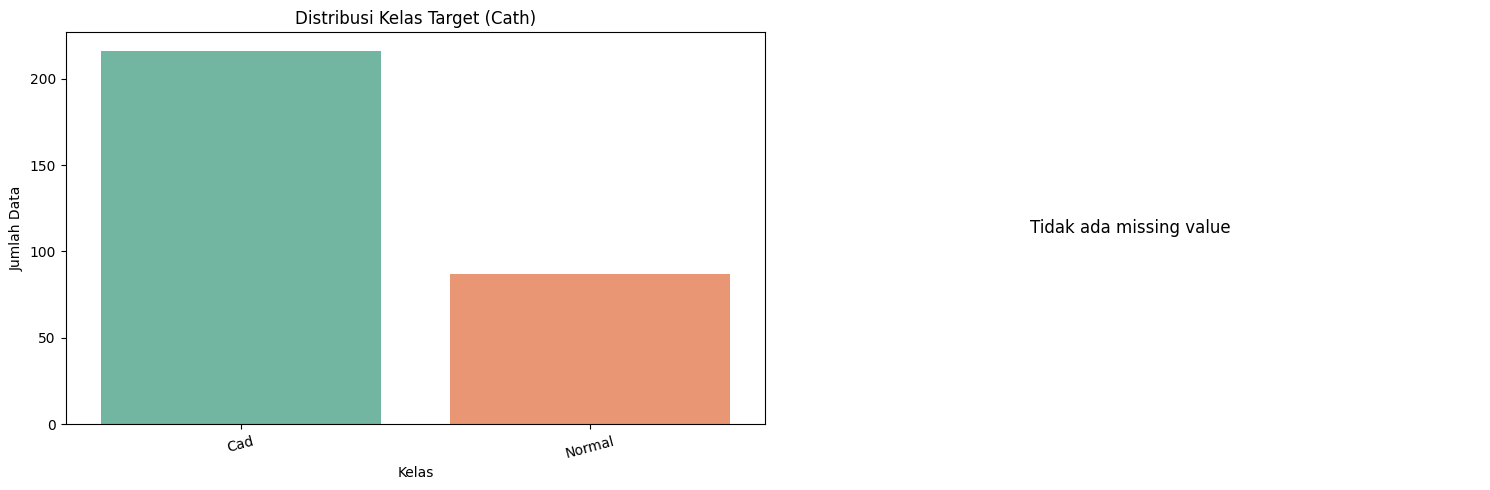

In [3]:
candidate_targets = ["Class", "class", "target", "label", "diagnosis", "Class Label"]
visual_target_col = next((c for c in candidate_targets if c in df.columns), df.columns[-1])
visual_df = df.dropna(subset=[visual_target_col]).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(
    data=visual_df,
    x=visual_target_col,
    order=visual_df[visual_target_col].value_counts().index,
    ax=axes[0],
    palette="Set2"
)
axes[0].set_title(f"Distribusi Kelas Target ({visual_target_col})")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Data")
axes[0].tick_params(axis="x", rotation=15)

missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0]
if missing_counts.empty:
    axes[1].text(0.5, 0.5, "Tidak ada missing value", ha="center", va="center", fontsize=12)
    axes[1].set_axis_off()
else:
    sns.barplot(x=missing_counts.index, y=missing_counts.values, ax=axes[1], palette="crest")
    axes[1].set_title("Jumlah Missing Value per Kolom")
    axes[1].set_xlabel("Kolom")
    axes[1].set_ylabel("Jumlah Missing")
    axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 2. Split Data (Train/Test)
Pada langkah ini dilakukan persiapan data sebelum pemodelan.
1. Menentukan kolom target secara otomatis dari beberapa kandidat nama kolom.
2. Memisahkan fitur (`X`) dan target (`y`).
3. Membersihkan nilai hilang pada fitur.
4. Mengubah fitur kategorikal menjadi numerik dengan one-hot encoding.
5. Membagi data menjadi data latih (80%) dan data uji (20%) menggunakan `stratify` agar proporsi kelas tetap seimbang.

In [4]:
candidate_targets = ["Class", "class", "target", "label", "diagnosis", "Class Label"]
target_col = next((c for c in candidate_targets if c in df.columns), df.columns[-1])

# Memisahkan fitur dan target
df = df.dropna(subset=[target_col]).copy()
X = df.drop(columns=[target_col])
y = df[target_col]

# Mengganti penanda missing value yang umum pada dataset ini
X = X.replace("?", np.nan)

# Mengisi missing value: numerik dengan median, kategorikal dengan modus
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].fillna(X[col].mode(dropna=True)[0])
    else:
        X[col] = X[col].fillna(X[col].median())

# Mengubah kategori menjadi fitur numerik
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Kolom target yang digunakan: {target_col}")
print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji  : {len(X_test)}")
print(f"Jumlah fitur setelah encoding: {X.shape[1]}")

Kolom target yang digunakan: Cath
Jumlah data latih: 242
Jumlah data uji  : 61
Jumlah fitur setelah encoding: 56


## 3. Klasifikasi Naive Bayes
Pada langkah ini model `GaussianNB` dibuat dan dilatih menggunakan data latih (`X_train`, `y_train`). Setelah pelatihan selesai, model digunakan untuk memprediksi kelas pada data uji sehingga dihasilkan `y_pred_nb`. Hasil ini akan dipakai sebagai pembanding untuk Random Forest.

In [5]:
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)
print("Model Naive Bayes selesai dilatih dan prediksi telah dibuat.")

Model Naive Bayes selesai dilatih dan prediksi telah dibuat.


## 4. Klasifikasi Random Forest
Pada langkah ini model `RandomForestClassifier` dibuat dan dilatih menggunakan data latih (`X_train`, `y_train`). Random Forest memakai banyak decision tree, lalu menggabungkan hasilnya untuk membuat prediksi yang biasanya lebih stabil dibandingkan model tunggal.

In [6]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
print("Model Random Forest selesai dilatih dan prediksi telah dibuat.")

Model Random Forest selesai dilatih dan prediksi telah dibuat.


## 5. Evaluasi Performansi dan Perbandingan
Pada langkah ini performa kedua model dinilai menggunakan data uji.
Metrik yang dihitung adalah Accuracy, Precision, Recall, dan F1-Score (weighted), lalu ditampilkan juga Confusion Matrix serta Classification Report untuk melihat performa per kelas. Hasil Random Forest kemudian dibandingkan langsung dengan Naive Bayes.

In [7]:
def hitung_metrik(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

hasil_nb = hitung_metrik(y_test, y_pred_nb)
hasil_rf = hitung_metrik(y_test, y_pred_rf)

hasil_perbandingan = pd.DataFrame([hasil_nb, hasil_rf], index=["Naive Bayes", "Random Forest"])
print("=== Perbandingan Performa Model ===")
print(hasil_perbandingan)

print("\n=== Confusion Matrix Naive Bayes ===")
print(confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report Naive Bayes:")
print(classification_report(y_test, y_pred_nb, zero_division=0))

print("\n=== Confusion Matrix Random Forest ===")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report Random Forest:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

model_terbaik = hasil_perbandingan["F1-Score"].idxmax()
print(f"\nModel dengan F1-Score terbaik: {model_terbaik}")

=== Perbandingan Performa Model ===
               Accuracy  Precision    Recall  F1-Score
Naive Bayes    0.737705   0.783246  0.737705  0.748099
Random Forest  0.836066   0.835731  0.836066  0.825018

=== Confusion Matrix Naive Bayes ===
[[31 12]
 [ 4 14]]

Classification Report Naive Bayes:
              precision    recall  f1-score   support

         Cad       0.89      0.72      0.79        43
      Normal       0.54      0.78      0.64        18

    accuracy                           0.74        61
   macro avg       0.71      0.75      0.72        61
weighted avg       0.78      0.74      0.75        61


=== Confusion Matrix Random Forest ===
[[41  2]
 [ 8 10]]

Classification Report Random Forest:
              precision    recall  f1-score   support

         Cad       0.84      0.95      0.89        43
      Normal       0.83      0.56      0.67        18

    accuracy                           0.84        61
   macro avg       0.84      0.75      0.78        61
weighted a

## 6. Kesimpulan
Berdasarkan hasil klasifikasi pada dataset CAD Alizadeh, Random Forest dan Naive Bayes sama-sama mampu melakukan prediksi kelas, tetapi performanya dibandingkan menggunakan accuracy, precision, recall, dan F1-score.
Dari tabel perbandingan, model dengan F1-score tertinggi dapat dianggap sebagai model terbaik untuk data ini. Pada umumnya Random Forest cenderung memberikan hasil yang lebih baik karena mampu menangkap pola hubungan antar fitur dengan lebih fleksibel dibandingkan Naive Bayes.
Jadi, jika hasil evaluasi menunjukkan Random Forest unggul, maka model tersebut lebih disarankan untuk klasifikasi CAD Alizadeh pada pembagian data yang digunakan di notebook ini.


# MLP

## 1. Import Library

Library yang digunakan:
- `pandas` & `numpy` — manipulasi data
- `matplotlib` & `seaborn` — visualisasi
- `sklearn.neural_network.MLPClassifier` — implementasi MLP
- `sklearn.model_selection.GridSearchCV` — hyperparameter tuning
- `sklearn.preprocessing.StandardScaler` — normalisasi fitur (wajib untuk MLP)
- `sklearn.pipeline.Pipeline` — menyatukan scaler dan model dalam satu alur
- Library Naive Bayes & Random Forest dari Partisipatif 3 untuk perbandingan

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

## 2. Load & Eksplorasi Data

Dataset **CAD Alizadeh** dibaca dari file Excel.  
Kolom target dideteksi secara otomatis dari kandidat nama umum (`Class`, `class`, `target`, dll.).  
Kita tampilkan 5 baris pertama, ukuran data, dan ringkasan statistik.

In [21]:
df = pd.read_excel('CADalizadeh.xls')

print(f"Ukuran dataset: {df.shape[0]} baris x {df.shape[1]} kolom")
print("\n5 Baris Pertama:")
display(df.head())

candidate_targets = ["Class", "class", "target", "label", "diagnosis", "Class Label"]
target_col = next((c for c in candidate_targets if c in df.columns), df.columns[-1])
print(f"\nKolom target yang terdeteksi: '{target_col}'")
print(f"Distribusi kelas:\n{df[target_col].value_counts()}")

Ukuran dataset: 303 baris x 56 kolom

5 Baris Pertama:


,No,Age,Weight,Length,Sex,BMI,DM,HTN,Current Smoker,EX-Smoker,...,K,Na,WBC,Lymph,Neut,PLT,EF-TTE,Region RWMA,VHD,Cath
0,1,53,90,175,Male,29.387755,0,1,1,0,...,4.7,141,5700,39,52,261,50,0,N,Cad
1,2,67,70,157,Fmale,28.398718,0,1,0,0,...,4.7,156,7700,38,55,165,40,4,N,Cad
2,3,54,54,164,Male,20.077335,0,0,1,0,...,4.7,139,7400,38,60,230,40,2,mild,Cad
3,4,66,67,158,Fmale,26.838648,0,1,0,0,...,4.4,142,13000,18,72,742,55,0,Severe,Normal
4,5,50,87,153,Fmale,37.165193,0,1,0,0,...,4.0,140,9200,55,39,274,50,0,Severe,Normal



Kolom target yang terdeteksi: 'Cath'
Distribusi kelas:
Cath
Cad       216
Normal     87
Name: count, dtype: int64


## 2.1 Visualisasi Awal Data

Menampilkan:
- **Distribusi kelas target** — untuk melihat apakah data seimbang atau tidak
- **Missing value** — kolom mana yang memiliki nilai kosong

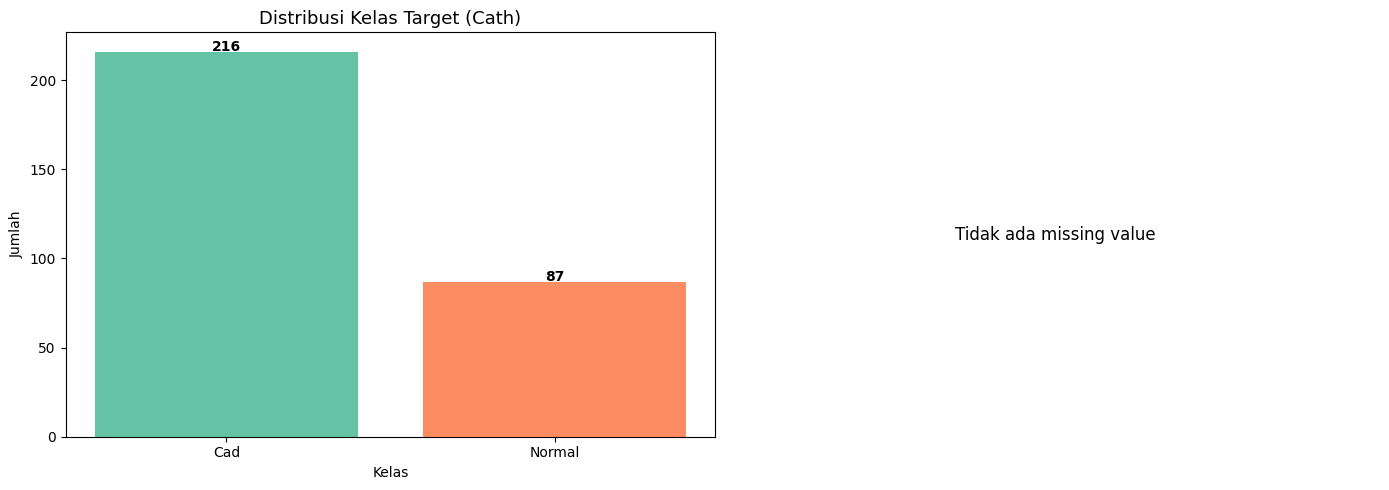

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

kelas_counts = df[target_col].value_counts()
axes[0].bar(kelas_counts.index.astype(str), kelas_counts.values,
            color=sns.color_palette('Set2', len(kelas_counts)))
axes[0].set_title(f'Distribusi Kelas Target ({target_col})', fontsize=13)
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(kelas_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

missing = df.isna().sum()
missing = missing[missing > 0]
if missing.empty:
    axes[1].text(0.5, 0.5, 'Tidak ada missing value', ha='center',
                 va='center', fontsize=12, transform=axes[1].transAxes)
    axes[1].set_axis_off()
else:
    axes[1].bar(missing.index, missing.values, color='salmon')
    axes[1].set_title('Missing Value per Kolom', fontsize=13)
    axes[1].set_xlabel('Kolom')
    axes[1].set_ylabel('Jumlah Missing')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Preprocessing Data

Langkah preprocessing yang dilakukan:
1. **Drop baris** dengan target kosong
2. **Pisahkan fitur (X) dan target (y)**
3. **Ganti simbol `?`** yang sering dipakai sebagai penanda missing value
4. **Imputasi missing value** — numerik → median, kategorikal → modus
5. **One-Hot Encoding** — mengubah kolom kategorikal menjadi numerik
6. **Split data** — 80% train, 20% test (stratified)
7. **StandardScaler** — WAJIB untuk MLP agar setiap fitur berada pada skala yang sama; difit hanya pada data train untuk menghindari data leakage

In [ ]:
df_clean = df.dropna(subset=[target_col]).copy()

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

X = X.replace('?', np.nan)

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].fillna(X[col].mode(dropna=True)[0])
    else:
        X[col] = X[col].fillna(X[col].median())

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Jumlah data latih  : {X_train.shape[0]}")
print(f"Jumlah data uji    : {X_test.shape[0]}")
print(f"Jumlah fitur       : {X_train.shape[1]}")
print(f"Distribusi kelas train:\n{y_train.value_counts()}")

Jumlah data latih  : 242
Jumlah data uji    : 61
Jumlah fitur       : 56
Distribusi kelas train:
Cath
Cad       173
Normal     69
Name: count, dtype: int64


## 4. Klasifikasi MLP — Model Dasar (Baseline)

Sebelum hyperparameter tuning, kita latih **MLP Baseline** dengan konfigurasi default sebagai patokan awal.  
Parameter yang digunakan:
- hidden_layer_sizes=(100,) — satu hidden layer dengan 100 neuron
- activation='relu' — fungsi aktivasi ReLU
- solver='adam' — optimizer Adam
- max_iter=300 — maksimum iterasi training
- random_state=42 — agar hasil reproducible

In [ ]:
mlp_base = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

mlp_base.fit(X_train_scaled, y_train)
y_pred_mlp_base = mlp_base.predict(X_test_scaled)

cv_scores_base = cross_val_score(
    mlp_base, X_train_scaled, y_train, cv=5, scoring='f1_weighted'
)

print("=== MLP Baseline ===")
print(f"Jumlah iterasi konvergen : {mlp_base.n_iter_}")
print(f"CV F1 (5-fold) mean±std  : {cv_scores_base.mean():.4f} ± {cv_scores_base.std():.4f}")
print(f"Akurasi pada test set    : {accuracy_score(y_test, y_pred_mlp_base):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp_base, zero_division=0))

=== MLP Baseline ===
Jumlah iterasi konvergen : 266
CV F1 (5-fold) mean±std  : 0.8605 ± 0.0401
Akurasi pada test set    : 0.8033

Classification Report:
              precision    recall  f1-score   support

         Cad       0.86      0.86      0.86        43
      Normal       0.67      0.67      0.67        18

    accuracy                           0.80        61
   macro avg       0.76      0.76      0.76        61
weighted avg       0.80      0.80      0.80        61



## 5. Hyperparameter Tuning MLP dengan GridSearchCV

**Hyperparameter tuning** adalah proses mencari kombinasi parameter terbaik untuk sebuah model.  
Kita menggunakan **GridSearchCV** yang mencoba semua kombinasi parameter secara sistematis.

Parameter yang di-tune:
| Parameter | Pilihan | Keterangan |
|---|---|---|
| hidden_layer_sizes | (50,), (100,), (100,50), (100,100) | Arsitektur jaringan |
| activation | relu, tanh | Fungsi aktivasi |
| solver | adam, sgd | Algoritma optimasi |
| alpha | 0.0001, 0.001, 0.01 | Regularisasi L2 |
| learning_rate | constant, adaptive | Strategi learning rate |

Evaluasi menggunakan **5-fold cross-validation** dengan metrik **F1-Score weighted**.

In [22]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 100)],
    'activation'        : ['relu', 'tanh'],
    'solver'            : ['adam', 'sgd'],
    'alpha'             : [0.0001, 0.001, 0.01],
    'learning_rate'     : ['constant', 'adaptive'],
}

mlp_gs = MLPClassifier(max_iter=500, random_state=42)

grid_search = GridSearchCV(
    estimator=mlp_gs,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,         
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\nGridSearchCV selesai!")
print(f"Best CV F1-Score  : {grid_search.best_score_:.4f}")
print(f"Best Parameters   :")
for k, v in grid_search.best_params_.items():
    print(f"  {k:25s}: {v}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits

GridSearchCV selesai!
Best CV F1-Score  : 0.8897
Best Parameters   :
  activation               : tanh
  alpha                    : 0.0001
  hidden_layer_sizes       : (100, 100)
  learning_rate            : constant
  solver                   : sgd


## 6. Evaluasi MLP Terbaik (Setelah Tuning)

Model dengan parameter terbaik hasil GridSearchCV dievaluasi pada **data test** yang belum pernah dilihat model sebelumnya.  
Ini memberikan estimasi performa yang tidak bias.

=== MLP Terbaik (setelah Hyperparameter Tuning) ===
Jumlah iterasi   : 500
Akurasi test set : 0.8197

Classification Report:
              precision    recall  f1-score   support

         Cad       0.85      0.91      0.88        43
      Normal       0.73      0.61      0.67        18

    accuracy                           0.82        61
   macro avg       0.79      0.76      0.77        61
weighted avg       0.81      0.82      0.81        61



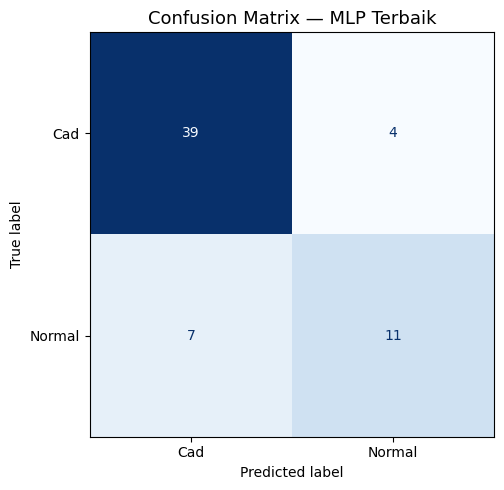

In [ ]:
best_mlp = grid_search.best_estimator_
y_pred_mlp_best = best_mlp.predict(X_test_scaled)

print("=== MLP Terbaik (setelah Hyperparameter Tuning) ===")
print(f"Jumlah iterasi   : {best_mlp.n_iter_}")
print(f"Akurasi test set : {accuracy_score(y_test, y_pred_mlp_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp_best, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
cm_mlp = confusion_matrix(y_test, y_pred_mlp_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp,
                               display_labels=best_mlp.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — MLP Terbaik', fontsize=13)
plt.tight_layout()
plt.show()

## 6.1 Visualisasi Proses Tuning

Grafik berikut menampilkan **Top 20 kombinasi parameter** terbaik berdasarkan CV F1-Score,  
sehingga kita dapat melihat rentang performa yang dicapai selama tuning.

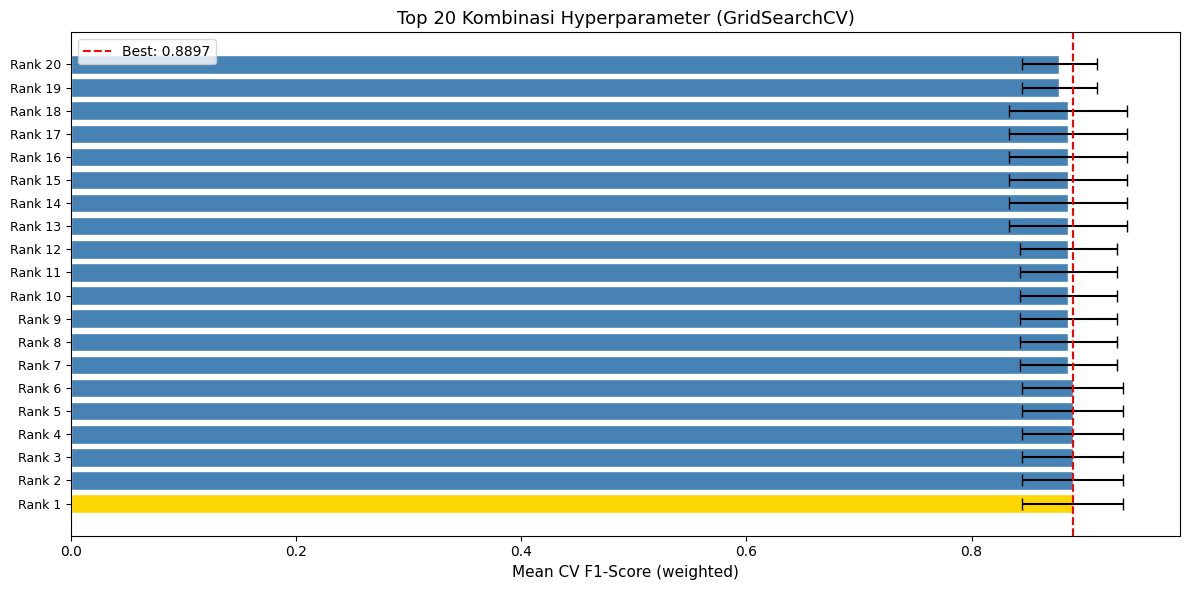

Top 5 Kombinasi Terbaik:


,mean_test_score,std_test_score,param_hidden_layer_sizes,param_activation,param_solver,param_alpha,param_learning_rate
0,0.889728,0.045273,"(100, 100)",tanh,sgd,0.0001,constant
1,0.889728,0.045273,"(100, 100)",tanh,sgd,0.0001,adaptive
2,0.889728,0.045273,"(100, 100)",tanh,sgd,0.0010,constant
3,0.889728,0.045273,"(100, 100)",tanh,sgd,0.0010,adaptive
4,0.889728,0.045273,"(100, 100)",tanh,sgd,0.0100,constant


In [15]:
cv_results = pd.DataFrame(grid_search.cv_results_)
top20 = cv_results.nlargest(20, 'mean_test_score').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(top20))]
bars = ax.barh(range(len(top20)), top20['mean_test_score'], xerr=top20['std_test_score'],
               color=colors, capsize=4, edgecolor='white')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f"Rank {i+1}" for i in range(len(top20))], fontsize=9)
ax.set_xlabel('Mean CV F1-Score (weighted)', fontsize=11)
ax.set_title('Top 20 Kombinasi Hyperparameter (GridSearchCV)', fontsize=13)
ax.axvline(grid_search.best_score_, color='red', linestyle='--', label=f'Best: {grid_search.best_score_:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

print("Top 5 Kombinasi Terbaik:")
cols_show = ['mean_test_score', 'std_test_score',
             'param_hidden_layer_sizes', 'param_activation',
             'param_solver', 'param_alpha', 'param_learning_rate']
display(top20[cols_show].head())

## 7. Perbandingan Semua Model

Pada tahap ini kita melatih ulang **Naive Bayes** dan **Random Forest** (sama persis dengan Partisipatif 3)  
pada data yang identik, lalu membandingkan performa keempat model:

| Model | Keterangan |
|---|---|
| Naive Bayes | Dari Partisipatif 3 |
| Random Forest | Dari Partisipatif 3 |
| MLP Baseline | MLP dengan parameter default |
| MLP Tuned | MLP setelah GridSearchCV |

**Catatan:** Naive Bayes & Random Forest tidak membutuhkan data yang sudah di-scale, sehingga menggunakan `X_train` / `X_test` tanpa StandardScaler.

In [29]:
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)

model_rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)


In [28]:
def hitung_metrik(y_true, y_pred, nama_model):
    return {
        'Model'    : nama_model,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }

hasil_semua = [
    hitung_metrik(y_test, y_pred_nb,       'Naive Bayes        (P3)'),
    hitung_metrik(y_test, y_pred_rf,       'Random Forest      (P3)'),
    hitung_metrik(y_test, y_pred_mlp_base, 'MLP Baseline       (P4)'),
    hitung_metrik(y_test, y_pred_mlp_best, 'MLP Tuned          (P4)'),
]

df_hasil = pd.DataFrame(hasil_semua).set_index('Model')

print("=" * 31)
print("  TABEL PERBANDINGAN PERFORMA")
print("=" * 31)
display(df_hasil)

model_terbaik = df_hasil['F1-Score'].idxmax()
print(f"\nModel terbaik berdasarkan F1-Score: {model_terbaik.strip()}")

  TABEL PERBANDINGAN PERFORMA


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Naive Bayes (P3),0.7377,0.7832,0.7377,0.7481
Random Forest (P3),0.8361,0.8357,0.8361,0.8250
MLP Baseline (P4),0.8033,0.8033,0.8033,0.8033
MLP Tuned (P4),0.8197,0.8140,0.8197,0.8145



Model terbaik berdasarkan F1-Score: Random Forest      (P3)


## 7.1 Visualisasi Perbandingan Performa

Grafik batang berkelompok memudahkan kita melihat secara visual perbedaan performa  
keempat model pada keempat metrik evaluasi.

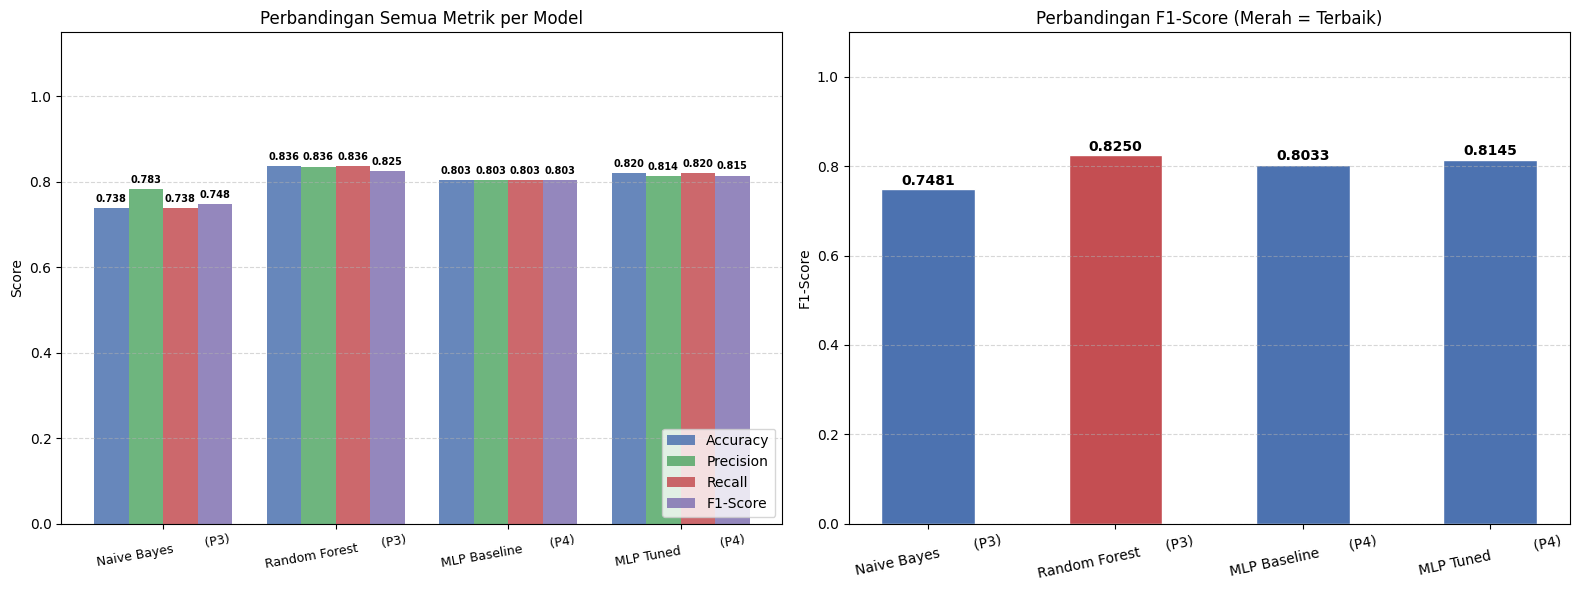

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_plot = df_hasil.copy()
df_plot.index = [idx.strip() for idx in df_plot.index]  # strip whitespace untuk label
x = np.arange(len(df_plot))
width = 0.2
metriks = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for i, (metrik, color) in enumerate(zip(metriks, colors)):
    axes[0].bar(x + i*width, df_plot[metrik], width, label=metrik, color=color, alpha=0.85)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(df_plot.index, fontsize=9, rotation=10)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score')
axes[0].set_title('Perbandingan Semua Metrik per Model', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for i, (metrik, color) in enumerate(zip(metriks, colors)):
    for j, val in enumerate(df_plot[metrik]):
        axes[0].text(j + i*width, val + 0.01, f'{val:.3f}', ha='center',
                     va='bottom', fontsize=7, fontweight='bold')

f1_vals = df_plot['F1-Score']
bar_colors = ['#C44E52' if v == f1_vals.max() else '#4C72B0' for v in f1_vals]
axes[1].bar(df_plot.index, f1_vals, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Perbandingan F1-Score (Merah = Terbaik)', fontsize=12)
axes[1].tick_params(axis='x', rotation=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate(f1_vals):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

## 7.2 Confusion Matrix Semua Model

Confusion Matrix menampilkan rincian prediksi benar dan salah per kelas untuk masing-masing model.

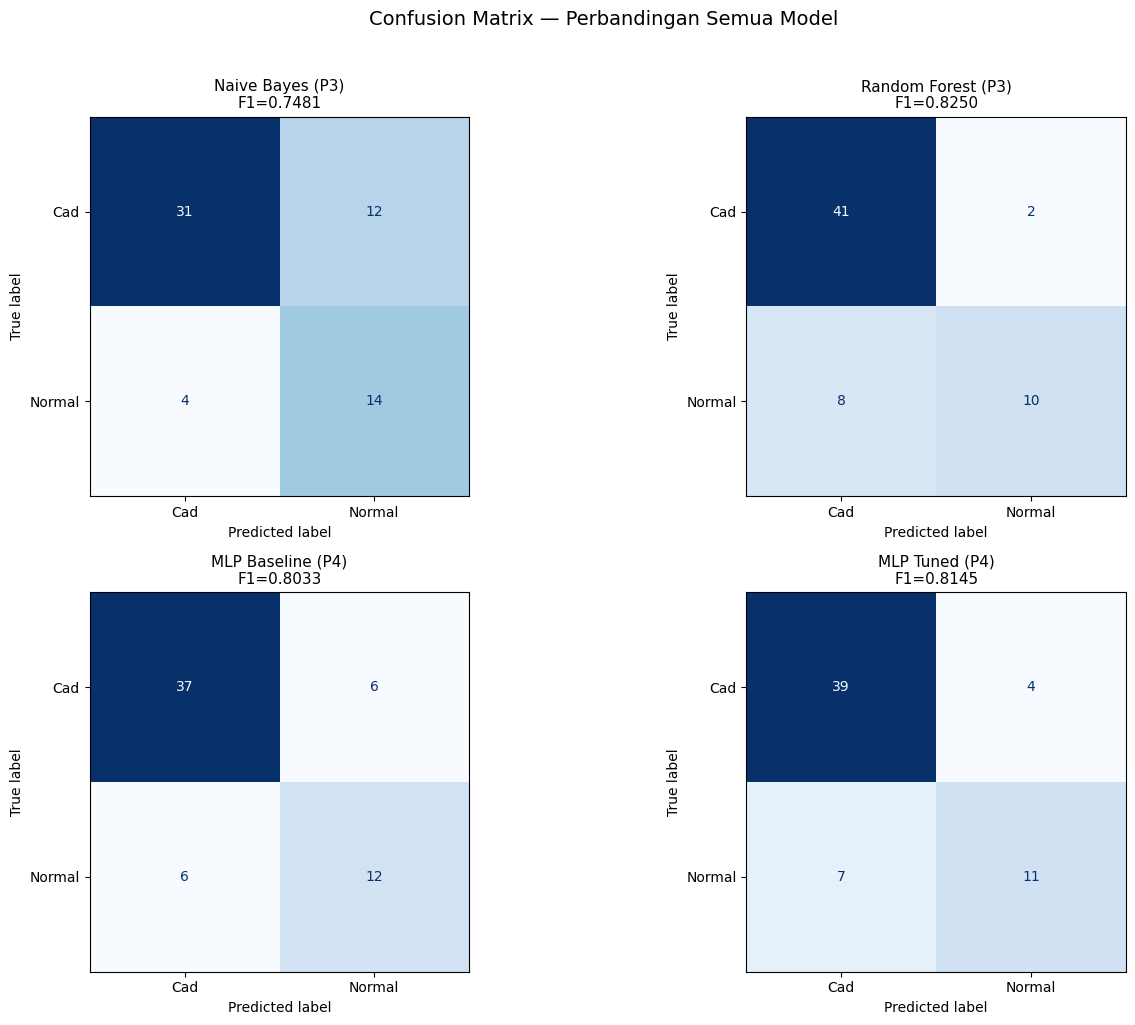

In [19]:
models_info = [
    ('Naive Bayes (P3)',        y_pred_nb,       None),
    ('Random Forest (P3)',      y_pred_rf,        None),
    ('MLP Baseline (P4)',       y_pred_mlp_base,  best_mlp.classes_),
    ('MLP Tuned (P4)',          y_pred_mlp_best,  best_mlp.classes_),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (nama, y_pred, classes) in enumerate(models_info):
    cm = confusion_matrix(y_test, y_pred)
    if classes is None:
        labels = sorted(y_test.unique())
    else:
        labels = classes
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    axes[i].set_title(f'{nama}\nF1={f1:.4f}', fontsize=11)

plt.suptitle('Confusion Matrix — Perbandingan Semua Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Kesimpulan

### Ringkasan Proses

| Langkah | Keterangan |
|---|---|
| Load Data | Dataset CAD Alizadeh dibaca dari Excel |
| Preprocessing | Imputasi missing value, One-Hot Encoding, StandardScaler |
| MLP Baseline | Satu hidden layer (100 neuron), parameter default |
| GridSearchCV | 5-fold CV, cari kombinasi terbaik dari 96 kemungkinan |
| MLP Terbaik | Model dengan F1-CV terbaik dievaluasi di test set |
| Perbandingan | Dibandingkan dengan Naive Bayes & Random Forest (P3) |

### Analisis Perbandingan

1. **Naive Bayes** — Model sederhana yang berasumsi independensi antar fitur. Performa cenderung lebih rendah karena asumsi tersebut sering tidak terpenuhi pada data medis.

2. **Random Forest** — Model ensemble yang kuat, tidak memerlukan scaling, dan mampu menangani fitur yang berkorelasi. Umumnya memberikan performa yang baik.

3. **MLP Baseline** — Sudah mampu menangkap pola non-linear berkat hidden layer, namun belum dioptimalkan.

4. **MLP Tuned** — Setelah GridSearchCV, performa MLP meningkat karena arsitektur dan hyperparameter disesuaikan dengan karakteristik data CAD Alizadeh.

### Kelebihan MLP dibanding Metode Sebelumnya
- Mampu memodelkan **hubungan non-linear** yang kompleks antar fitur
- Dengan jumlah hidden layer dan neuron yang tepat, MLP dapat merepresentasikan fungsi klasifikasi yang lebih ekspresif
- Hyperparameter tuning memungkinkan model disesuaikan secara sistematis dengan data

### Rekomendasi
Model dengan **F1-Score tertinggi** pada tabel perbandingan adalah pilihan terbaik untuk klasifikasi CAD Alizadeh.  
Untuk deployment, pertimbangkan juga **waktu inferensi** dan **interpretabilitas** model sesuai kebutuhan klinis.